In [1]:
# Install required packages


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings; warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)
sns.set_style("whitegrid")
print("Libraries imported successfully")


Libraries imported successfully


In [2]:
# Load the customer Excel file
df = pd.read_excel(
    r'C:\Users\ankii\OneDrive\Desktop\Customer_Purchasing_Analysis\Data\Cleaned Data\Customer_Data_Cleaned.xlsx',
    sheet_name="Customer_Data_Cleaned"
    # Note: NO parse_dates — this dataset has no date column
)

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Dataset loaded: 3,900 rows x 18 columns
Memory usage: 2.80 MB


In [3]:
df.head(3)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [5]:
df[['Age','Purchase Amount (USD)','Review Rating','Previous Purchases']].describe().round(2)

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.00,3900.00,3863.00,3900.00
mean,44.07,59.76,3.75,25.35
std,15.21,23.69,0.72,14.45
min,18.00,20.00,2.50,1.00
25%,31.00,39.00,3.10,13.00
50%,44.00,60.00,3.80,25.00
75%,57.00,81.00,4.40,38.00
max,70.00,100.00,5.00,50.00


In [6]:
# Count nulls per column
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"\nTotal null cells: {missing.sum()}")
print(f"Null %: {missing.sum() / df.size * 100:.3f}%")

Review Rating    37
dtype: int64

Total null cells: 37
Null %: 0.053%


In [7]:
# Full row duplicates
full_dups = df.duplicated().sum()

# Customer ID uniqueness
id_dups = df.duplicated(subset=["Customer ID"]).sum()
is_sequential = (df["Customer ID"].sort_values().diff().dropna() == 1).all()

print(f"Full duplicate rows:    {full_dups}")
print(f"Duplicate Customer IDs: {id_dups}")
print(f"IDs are sequential 1-3900: {is_sequential}")


Full duplicate rows:    0
Duplicate Customer IDs: 0
IDs are sequential 1-3900: True


In [8]:
# Confirm all column types
print(df.dtypes)

# Specific type assertions
assert df["Customer ID"].dtype == "int64", "ID should be int"
# Confirm all column types
print(df.dtypes)

# Specific type assertions
assert df["Customer ID"].dtype == "int64", "ID should be int"
assert df["Age"].dtype == "int64", "Age should be int"
assert df["Purchase Amount (USD)"].dtype == "int64", "Amount should be int"
assert df["Review Rating"].dtype == "float64", "Rating should be float"
print("All type assertions PASSED")


Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object
dtype: object
Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64


In [9]:
# Range checks for all numeric columns
print(f"Age:               {df.Age.min()}-{df.Age.max()} (expected 18-70)")
print(f"Purchase Amount:   ${df["Purchase Amount (USD)"].min()}-${df["Purchase Amount (USD)"].max()} (expected $20-$100)")
print(f"Review Rating:     {df["Review Rating"].min()}-{df["Review Rating"].max()} (expected 1-5)")
print(f"Previous Purchases:{df["Previous Purchases"].min()}-{df["Previous Purchases"].max()} (expected 1-50)")

# Anomaly checks
neg_amounts = (df["Purchase Amount (USD)"] < 0).sum()
age_oor = ((df.Age < 18) | (df.Age > 70)).sum()
print(f"Negative amounts: {neg_amounts}")
print(f"Age out of range: {age_oor}")


Age:               18-70 (expected 18-70)
Purchase Amount:   $20-$100 (expected $20-$100)
Review Rating:     2.5-5.0 (expected 1-5)
Previous Purchases:1-50 (expected 1-50)
Negative amounts: 0
Age out of range: 0


In [10]:
# Verify that Discount Applied and Promo Code Used are identical
mismatch = (df["Discount Applied"] != df["Promo Code Used"]).sum()
disc_yes = df["Discount Applied"].value_counts()
promo_yes = df["Promo Code Used"].value_counts()

print(f"Discount vs Promo mismatches: {mismatch}")
print(f"Discount Applied distribution: {disc_yes.to_dict()}")
print(f"Promo Code Used distribution:  {promo_yes.to_dict()}")

# Cross-tabulation
print(pd.crosstab(df["Discount Applied"], df["Promo Code Used"]))


Discount vs Promo mismatches: 0
Discount Applied distribution: {'No': 2223, 'Yes': 1677}
Promo Code Used distribution:  {'No': 2223, 'Yes': 1677}
Promo Code Used     No   Yes
Discount Applied            
No                2223     0
Yes                  0  1677


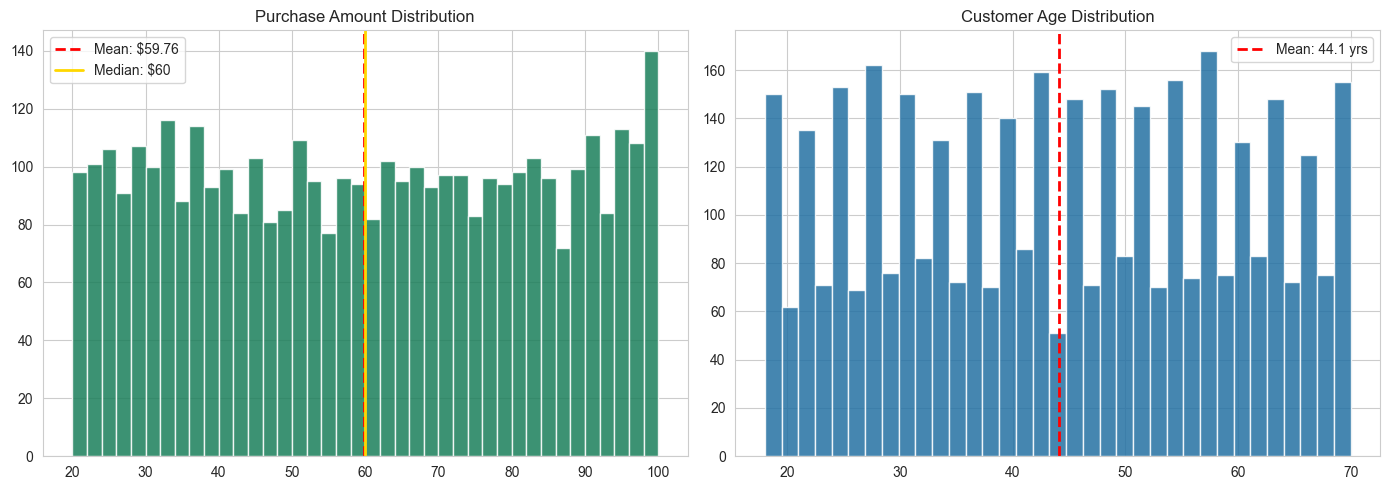

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Purchase Amount histogram
axes[0].hist(df["Purchase Amount (USD)"], bins=40, color="#1A7F5A", alpha=0.85)
axes[0].axvline(df["Purchase Amount (USD)"].mean(), color="red", lw=2, ls="--",
    label=f'Mean: ${df["Purchase Amount (USD)"].mean():.2f}')
axes[0].axvline(df["Purchase Amount (USD)"].median(), color="gold", lw=2,
    label=f'Median: ${df["Purchase Amount (USD)"].median():.0f}')
axes[0].set_title("Purchase Amount Distribution"); axes[0].legend()

# Age histogram
axes[1].hist(df["Age"], bins=35, color="#2471A3", alpha=0.85)
axes[1].axvline(df["Age"].mean(), color="red", lw=2, ls="--",
    label=f'Mean: {df["Age"].mean():.1f} yrs')
axes[1].set_title("Customer Age Distribution"); axes[1].legend()
plt.tight_layout(); plt.savefig("chart1_distribution.png")


             Total_Revenue  Avg_Amount  Customer_Count
Category                                              
Clothing            104264   60.025331            1737
Accessories          74200   59.838710            1240
Footwear             36093   60.255426             599
Outerwear            18524   57.172840             324
        Total_Revenue  Avg_Amount  Count
Gender                                  
Female          75191   60.249199   1248
Male           157890   59.536199   2652


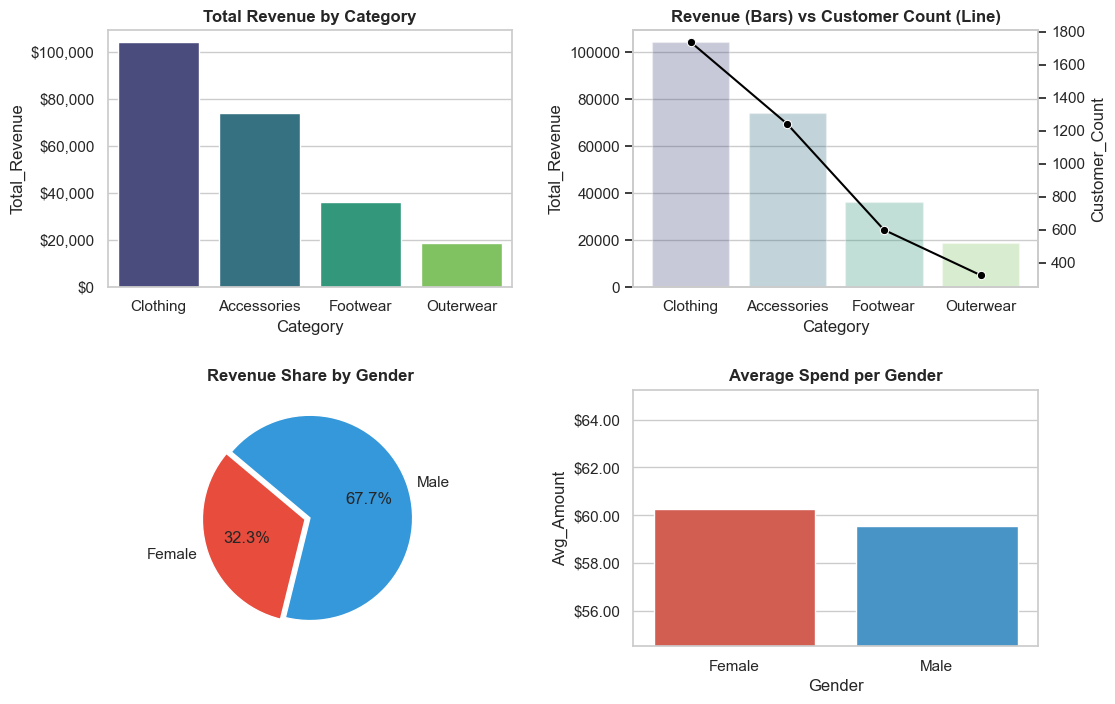

In [57]:
# Category revenue and averages
cat_stats = df.groupby("Category").agg(
    Total_Revenue=("Purchase Amount (USD)","sum"),
    Avg_Amount=("Purchase Amount (USD)","mean"),
    Customer_Count=("Customer ID","count")
).sort_values("Total_Revenue", ascending=False)
print(cat_stats)


# Gender analysis
gender_stats = df.groupby("Gender").agg(
    Total_Revenue=("Purchase Amount (USD)","sum"),
    Avg_Amount=("Purchase Amount (USD)","mean"),
    Count=("Customer ID","count")
)
print(gender_stats)


# --- 1. DATA PREP (Ensuring dataframes are ready for plotting) ---
cat_plot = cat_stats.reset_index()
gen_plot = gender_stats.reset_index()

# --- 2. COLOR CONSISTENCY ---
sns.set_theme(style="whitegrid")

# Assign fixed colors to Categories
cat_palette = dict(zip(cat_plot["Category"], sns.color_palette("viridis", len(cat_plot))))

# Assign fixed colors to Gender
# Using a specific palette for gender consistency
gen_palette = {"Male": "#3498db", "Female": "#e74c3c"} 

# --- 3. CREATE THE DASHBOARD (2 Rows, 2 Columns) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- TOP LEFT: Category Total Revenue (Bar) ---
sns.barplot(data=cat_plot, x="Category", y="Total_Revenue", palette=cat_palette, ax=axes[0, 0])
axes[0, 0].set_title("Total Revenue by Category", fontweight='bold')
axes[0, 0].yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

# --- TOP RIGHT: Category Revenue vs Count (Dual Axis) ---
# This shows two things in one chart: Revenue (Bars) and Count (Line)
sns.barplot(data=cat_plot, x="Category", y="Total_Revenue", alpha=0.3, palette=cat_palette, ax=axes[0, 1])
ax_twin = axes[0, 1].twinx()
sns.lineplot(data=cat_plot, x="Category", y="Customer_Count", color="black", marker="o", ax=ax_twin)
axes[0, 1].set_title("Revenue (Bars) vs Customer Count (Line)", fontweight='bold')
ax_twin.grid(False)

# --- BOTTOM LEFT: Gender Revenue Distribution (Pie Chart) ---
axes[1, 0].pie(gen_plot["Total_Revenue"], labels=gen_plot["Gender"], 
               autopct='%1.1f%%', colors=[gen_palette[g] for g in gen_plot["Gender"]],
               startangle=140, explode=(0.05, 0))
axes[1, 0].set_title("Revenue Share by Gender", fontweight='bold')

# --- BOTTOM RIGHT: Gender Avg Amount (Bar) ---
sns.barplot(data=gen_plot, x="Gender", y="Avg_Amount", palette=gen_palette, ax=axes[1, 1])
axes[1, 1].set_title("Average Spend per Gender", fontweight='bold')
axes[1, 1].yaxis.set_major_formatter(StrMethodFormatter('${x:,.2f}'))
# Set a tight limit to see small differences in averages
axes[1, 1].set_ylim(min(gen_plot["Avg_Amount"])-5, max(gen_plot["Avg_Amount"])+5)

plt.show()


        Total        Avg  Count
Season                         
Fall    60018  61.556923    975
Spring  58679  58.737738    999
Winter  58607  60.357364    971
Summer  55777  58.405236    955
                      Total        Avg  Count  Avg_Prev_Purchases
Subscription Status                                              
No                   170436  59.865121   2847           25.080436
Yes                   62645  59.491928   1053           26.084520


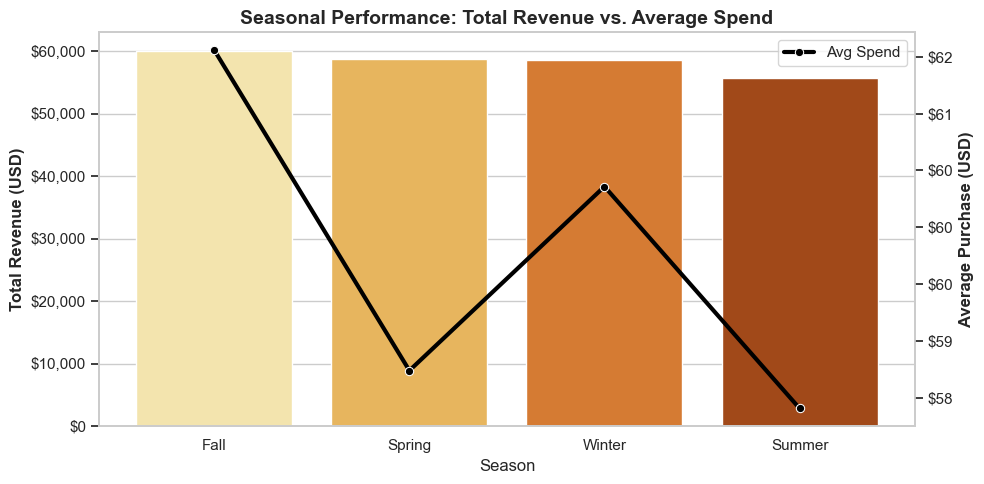

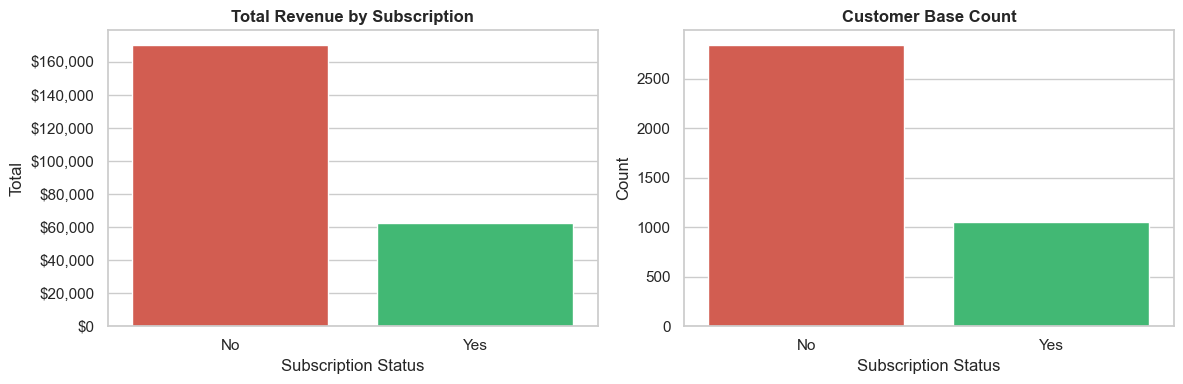

In [54]:
# Seasonal breakdown
season_stats = df.groupby("Season").agg(
    Total=("Purchase Amount (USD)","sum"),
    Avg=("Purchase Amount (USD)","mean"),
    Count=("Customer ID","count")
).sort_values("Total", ascending=False)
print(season_stats)

# Subscription comparison
sub_stats = df.groupby("Subscription Status").agg(
    Total=("Purchase Amount (USD)","sum"),
    Avg=("Purchase Amount (USD)","mean"),
    Count=("Customer ID","count"),
    Avg_Prev_Purchases=("Previous Purchases","mean")
)
print(sub_stats)



# --- 1. PREPARATION & COLOR MAPPING ---
sns.set_theme(style="whitegrid")

# Create a fixed color map for Seasons (so Fall is always Fall)
season_order = ['Fall', 'Spring', 'Winter', 'Summer']
season_colors = sns.color_palette("YlOrBr", 4) # Warm, seasonal-appropriate colors
season_palette = dict(zip(season_order, season_colors))

# Color map for Subscription
sub_palette = {"Yes": "#2ecc71", "No": "#e74c3c"} # Green for Yes, Red for No

# --- 2. SEASONAL DASHBOARD (Multiple Metrics in One) ---
# We reset index to make "Season" a column for Seaborn
season_plot_data = season_stats.reindex(season_order).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bars for Total Revenue
sns.barplot(data=season_plot_data, x="Season", y="Total", palette=season_palette, ax=ax1)
ax1.set_title("Seasonal Performance: Total Revenue vs. Average Spend", fontsize=14, fontweight='bold')
ax1.set_ylabel("Total Revenue (USD)", fontweight='bold')

# Create secondary axis for Average Spend
ax2 = ax1.twinx()
sns.lineplot(data=season_plot_data, x="Season", y="Avg", color="black", marker="o", linewidth=3, ax=ax2, label="Avg Spend")
ax2.set_ylabel("Average Purchase (USD)", fontweight='bold')
ax2.grid(False) # Hide extra grid lines

# Formatting
ax1.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax2.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.tight_layout()
plt.show()

# --- 3. SUBSCRIPTION DASHBOARD (Two Comparisons Side-by-Side) ---
sub_plot_data = sub_stats.reset_index()

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 4))

# Left: Total Revenue by Subscription
sns.barplot(data=sub_plot_data, x="Subscription Status", y="Total", palette=sub_palette, ax=ax3)
ax3.set_title("Total Revenue by Subscription", fontsize=12, fontweight='bold')
ax3.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

# Right: Count of Customers
sns.barplot(data=sub_plot_data, x="Subscription Status", y="Count", palette=sub_palette, ax=ax4)
ax4.set_title("Customer Base Count", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Payment Methods: {'PayPal': 677, 'Credit Card': 671, 'Cash': 670, 'Debit Card': 636, 'Venmo': 634, 'Bank Transfer': 612}
                        Count  Avg_Amount
Frequency of Purchases                   
Weekly                    539   58.972171
Fortnightly               542   59.053506
Bi-Weekly                 547   60.694698
Monthly                   553   59.330922
Every 3 Months            584   60.082192
Quarterly                 563   59.984014
Annually                  572   60.173077


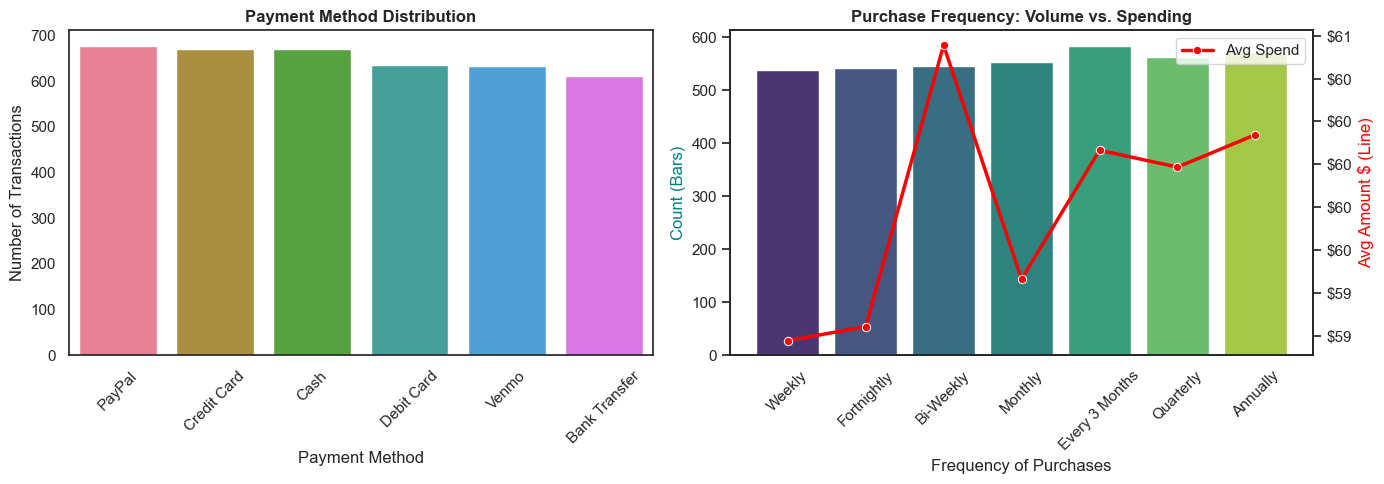

In [52]:
# Payment method distribution
payment_counts = df["Payment Method"].value_counts()
print("Payment Methods:", payment_counts.to_dict())

# Purchase frequency analysis
freq_order = {'Weekly':1,'Fortnightly':2,'Bi-Weekly':3,
              'Monthly':4,'Every 3 Months':5,'Quarterly':6,'Annually':7}
df["freq_order"] = df["Frequency of Purchases"].map(freq_order)
freq_stats = df.groupby("Frequency of Purchases").agg(
    Count=("Customer ID","count"),
    Avg_Amount=("Purchase Amount (USD)","mean")
).reindex(freq_order.keys())
print(freq_stats)


# --- 1. DATA PREP (Fixing the Index issue) ---
payment_df = df["Payment Method"].value_counts().reset_index()
payment_df.columns = ["Payment Method", "Count"]

freq_order = ['Weekly','Fortnightly','Bi-Weekly','Monthly', 
              'Every 3 Months','Quarterly', 'Annually']

freq_stats = df.groupby("Frequency of Purchases").agg(
    Count=("Customer ID","count"),
    Avg_Amount=("Purchase Amount (USD)","mean")
).reindex(freq_order).reset_index()

# --- 2. SETTINGS ---
sns.set_theme(style="white") # Cleaner background for subplots
freq_palette = sns.color_palette("viridis", len(freq_stats))

# --- 3. CREATE DASHBOARD (1 Row, 2 Columns) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5)) # Reduced height to 5

# --- LEFT CHART: Payment Methods ---
sns.barplot(data=payment_df, x="Payment Method", y="Count", palette="husl", ax=ax1)
ax1.set_title("Payment Method Distribution", fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylabel("Number of Transactions")

# --- RIGHT CHART: Combined Frequency (Dual Axis) ---
# Bar Chart for Count
sns.barplot(data=freq_stats, x="Frequency of Purchases", y="Count", palette=freq_palette, ax=ax2)
ax2.set_title("Purchase Frequency: Volume vs. Spending", fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.set_ylabel("Count (Bars)", color="teal")

# Secondary Y-Axis for Average Amount (Line Chart)
ax3 = ax2.twinx() 
sns.lineplot(data=freq_stats, x="Frequency of Purchases", y="Avg_Amount", 
             color="red", marker="o", linewidth=2.5, ax=ax3, label="Avg Spend")

ax3.set_ylabel("Avg Amount $ (Line)", color="red")
ax3.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax3.grid(False) # Hide overlapping grid lines

# Final touches
plt.tight_layout()
plt.show()

           Count  Avg_Amount
age_group                   
18-25        571   60.647986
26-35        742   59.760108
36-45        729   59.305898
46-55        753   60.583001
56-70       1105   59.055204

Avg Rating: 3.75
Median Rating: 3.8
Min: 2.5, Max: 5.0
% Rated 4.0+: 42.3%


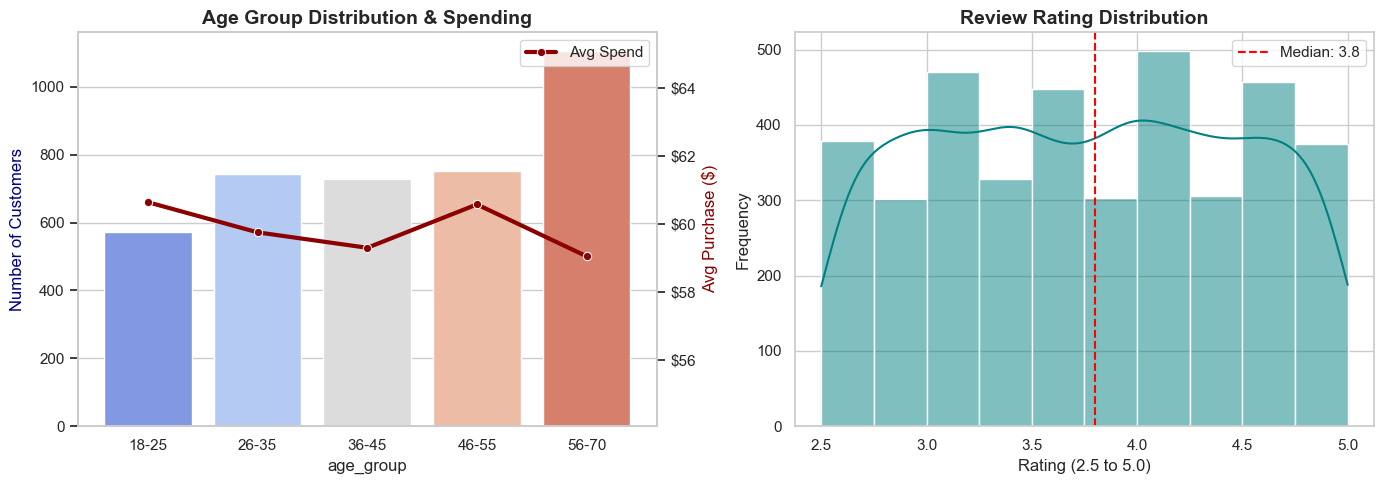

In [58]:
# Age group segmentation
bins = [17, 25, 35, 45, 55, 70]
labels = ["18-25","26-35","36-45","46-55","56-70"]
df["age_group"] = pd.cut(df["Age"], bins=bins, labels=labels)

age_stats = df.groupby("age_group", observed=True).agg(
    Count=("Customer ID","count"),
    Avg_Amount=("Purchase Amount (USD)","mean")
)
print(age_stats)

# Review rating distribution (excluding 37 nulls)
rating_clean = df["Review Rating"].dropna()
print(f"\nAvg Rating: {rating_clean.mean():.2f}")
print(f"Median Rating: {rating_clean.median():.1f}")
print(f"Min: {rating_clean.min()}, Max: {rating_clean.max()}")
print(f"% Rated 4.0+: {(rating_clean >= 4.0).sum() / len(rating_clean) * 100:.1f}%")



# --- 1. DATA PREP ---
# (Ensuring age_stats is ready for plotting)
age_plot_data = age_stats.reset_index()

# --- 2. STYLE & COLOR SETTINGS ---
sns.set_theme(style="whitegrid")
# Using a consistent color theme for Age Groups
age_palette = sns.color_palette("coolwarm", len(age_plot_data))

# --- 3. CREATE DASHBOARD (1 Row, 2 Columns) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- LEFT CHART: Age Group (Count vs Avg Spend) ---
# Bars for Count
sns.barplot(data=age_plot_data, x="age_group", y="Count", palette=age_palette, ax=ax1)
ax1.set_title("Age Group Distribution & Spending", fontsize=14, fontweight='bold')
ax1.set_ylabel("Number of Customers", color="navy")

# Line for Average Amount (Dual Axis)
ax1_twin = ax1.twinx()
sns.lineplot(data=age_plot_data, x="age_group", y="Avg_Amount", 
             color="darkred", marker="o", linewidth=3, ax=ax1_twin, label="Avg Spend")
ax1_twin.set_ylabel("Avg Purchase ($)", color="darkred")
ax1_twin.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax1_twin.set_ylim(age_plot_data["Avg_Amount"].min() - 5, age_plot_data["Avg_Amount"].max() + 5)
ax1_twin.grid(False)

# --- RIGHT CHART: Review Rating Distribution ---
# We'll use a Histogram with a KDE (Density) line for a "fuller" project look
sns.histplot(rating_clean, bins=10, kde=True, color="teal", ax=ax2)
ax2.set_title("Review Rating Distribution", fontsize=14, fontweight='bold')
ax2.set_xlabel("Rating (2.5 to 5.0)")
ax2.set_ylabel("Frequency")

# Adding a vertical line for the Median
median_val = rating_clean.median()
ax2.axvline(median_val, color='red', linestyle='--', label=f'Median: {median_val}')
ax2.legend()

# --- FINAL LAYOUT ADJUSTMENTS ---
plt.tight_layout()
plt.show()


                         Age  Purchase Amount (USD)  Previous Purchases  \
Age                    1.000                 -0.013               0.042   
Purchase Amount (USD) -0.013                  1.000               0.009   
Previous Purchases     0.042                  0.009               1.000   
Review Rating         -0.024                  0.030               0.004   

                       Review Rating  
Age                           -0.024  
Purchase Amount (USD)          0.030  
Previous Purchases             0.004  
Review Rating                  1.000  
Season        Fall  Spring  Summer  Winter
Category                                  
Accessories  19874   17007   19028   18291
Clothing     26220   27692   23078   27274
Footwear      8665    9555    9393    8480
Outerwear     5259    4425    4278    4562


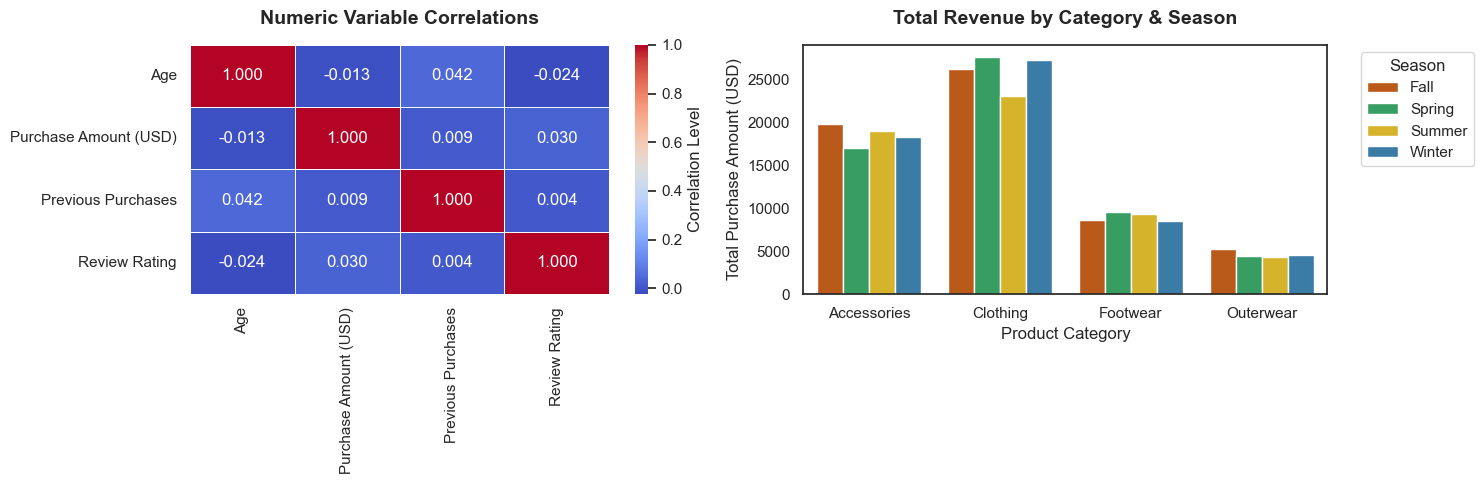

In [60]:
# Correlation matrix for numeric variables
num_cols = ["Age", "Purchase Amount (USD)", "Previous Purchases", "Review Rating"]
df_num = df[num_cols].dropna()  # Remove 37 null ratings
corr = df_num.corr().round(3)
print(corr)

# Category × Season revenue heatmap
cat_season = df.groupby(["Category","Season"])["Purchase Amount (USD)"].sum().unstack()
print(cat_season)



# --- 1. SETTINGS & COLOR PALETTE ---
sns.set_theme(style="white")

# Defining a consistent "Season" palette for your project
# Fall = Orange, Spring = Green, Summer = Yellow/Gold, Winter = Blue
season_palette = {
    "Fall": "#D35400",   # Burnt Orange
    "Spring": "#27AE60", # Emerald Green
    "Summer": "#F1C40F", # Sun Yellow
    "Winter": "#2980B9"  # Ocean Blue
}

# --- 2. CREATE DASHBOARD (1 Row, 2 Columns) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- LEFT CHART: Correlation Heatmap ---
# Using 'annot=True' to show the numbers inside the squares
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".3f", 
            linewidths=0.5, ax=ax1, cbar_kws={'label': 'Correlation Level'})
ax1.set_title("Numeric Variable Correlations", fontsize=14, fontweight='bold', pad=15)

# --- RIGHT CHART: Category x Season Revenue ---
# We pivot the cat_season back to a "long" format for Seaborn's barplot
cat_season_plot = cat_season.reset_index().melt(id_vars="Category", var_name="Season", value_name="Revenue")

sns.barplot(data=cat_season_plot, x="Category", y="Revenue", 
            hue="Season", palette=season_palette, ax=ax2)

ax2.set_title("Total Revenue by Category & Season", fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel("Total Purchase Amount (USD)")
ax2.set_xlabel("Product Category")
ax2.legend(title="Season", bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside

# Final Layout Adjustments
plt.tight_layout()
plt.show()

In [17]:
# Feature 1: Age Group (5-year bands)
bins   = [17, 25, 35, 45, 55, 70]
labels = ["18-25","26-35","36-45","46-55","56-70"]
df["age_group"] = pd.cut(df["Age"], bins=bins, labels=labels).astype(str)

# Feature 2: Generation label
def generation(age):
    if age <= 28:  return "Gen Z (18-28)"
    elif age <= 44: return "Millennial (29-44)"
    elif age <= 60: return "Gen X (45-60)"
    else:           return "Boomer (61-70)"
df["generation"] = df["Age"].apply(generation)

print(df["age_group"].value_counts().sort_index())
print(df["generation"].value_counts())


age_group
18-25     571
26-35     742
36-45     729
46-55     753
56-70    1105
Name: count, dtype: int64
generation
Gen X (45-60)         1207
Millennial (29-44)    1168
Gen Z (18-28)          802
Boomer (61-70)         723
Name: count, dtype: int64


In [18]:
# Feature 3: Purchase Tier
def purchase_tier(amt):
    if amt <= 30:  return "Budget (<=$30)"
    elif amt <= 60: return "Mid ($31-$60)"
    elif amt <= 80: return "Premium ($61-$80)"
    else:           return "Luxury ($81-$100)"
df["purchase_tier"] = df["Purchase Amount (USD)"].apply(purchase_tier)

# Feature 4: Loyalty Tier (based on previous purchases)
def loyalty_tier(prev):
    if prev <= 5:   return "New (1-5)"
    elif prev <= 10: return "Developing (6-10)"
    elif prev <= 25: return "Regular (11-25)"
    else:            return "Loyal (26-50)"
df["loyalty_tier"] = df["Previous Purchases"].apply(loyalty_tier)

print(df["purchase_tier"].value_counts())
print(df["loyalty_tier"].value_counts())


purchase_tier
Mid ($31-$60)        1435
Luxury ($81-$100)     978
Premium ($61-$80)     936
Budget (<=$30)        551
Name: count, dtype: int64
loyalty_tier
Loyal (26-50)        1935
Regular (11-25)      1181
New (1-5)             424
Developing (6-10)     360
Name: count, dtype: int64


In [19]:
# Feature 5: Frequency Order (numeric 1-7 for correct sorting)
freq_map = {
    "Weekly": 1, "Fortnightly": 2, "Bi-Weekly": 3,
    "Monthly": 4, "Every 3 Months": 5,
    "Quarterly": 6, "Annually": 7
}
df["freq_order"] = df["Frequency of Purchases"].map(freq_map)

# Feature 6: Frequency Category (simplified 3-tier)
def freq_category(order):
    if order <= 3: return "High Frequency (Weekly-Bi-Weekly)"
    elif order <= 5: return "Medium Frequency (Monthly-Quarterly)"
    else:            return "Low Frequency (Quarterly-Annually)"
df["frequency_category"] = df["freq_order"].apply(freq_category)

# Verify 99 (unmatched) = 0
print(f"Unmatched freq values: {(df.freq_order.isna()).sum()}")
print(df.groupby("frequency_category")["Purchase Amount (USD)"].mean().round(2))


Unmatched freq values: 0
frequency_category
High Frequency (Weekly-Bi-Weekly)       59.58
Low Frequency (Quarterly-Annually)      60.08
Medium Frequency (Monthly-Quarterly)    59.72
Name: Purchase Amount (USD), dtype: float64


In [20]:
# Feature 7-9: Normalised component scores (0 to 1 scale)
df["amt_score"]   = (df["Purchase Amount (USD)"] - 20) / 80  # $20=0, $100=1
df["loyal_score"] = (df["Previous Purchases"] - 1) / 49      # 1pur=0, 50pur=1
df["freq_score"]  = (7 - df["freq_order"]) / 6               # Weekly=1, Annual=0

# Feature 10: Composite Customer Value Score
df["customer_value_score"] = (
    df["amt_score"]   * 0.40 +  # Spending weight: 40%
    df["loyal_score"] * 0.35 +  # Loyalty weight: 35%
    df["freq_score"]  * 0.25    # Frequency weight: 25%
).round(3)

# Feature 11: Value Segment label
def value_segment(score):
    if score >= 0.65:  return "High Value"
    elif score >= 0.40: return "Medium Value"
    else:               return "Low Value"
df["value_segment"] = df["customer_value_score"].apply(value_segment)

print(f"Score range: {df.customer_value_score.min():.3f} to {df.customer_value_score.max():.3f}")
print(df.groupby("value_segment").agg(
    count=("Customer ID","count"),
    avg_score=("customer_value_score","mean"),
    avg_amount=("Purchase Amount (USD)","mean"),
    avg_loyal=("Previous Purchases","mean")
).round(2))


Score range: 0.021 to 0.995
               count  avg_score  avg_amount  avg_loyal
value_segment                                         
High Value       786       0.75       82.18      37.59
Low Value       1169       0.29       40.99      15.62
Medium Value    1945       0.52       61.99      26.26


In [21]:
# Feature 12: Promotional Engagement Segment
def promo_engagement(row):
    sub = row["Subscription Status"] == "Yes"
    disc = row["Discount Applied"] == "Yes"
    if sub and disc:    return "Engaged Subscriber"
    elif sub:           return "Passive Subscriber"
    elif disc:          return "Promo-Responsive"
    else:               return "Non-Engaged"
df["promo_engagement"] = df.apply(promo_engagement, axis=1)

# Feature 13: Seasonal Spend Index
season_avg = df.groupby("Season")["Purchase Amount (USD)"].mean()
df["seasonal_spend_index"] = df["Season"].map(season_avg).round(2)

# Feature 14: Rating Flag
df["rating_flag"] = df["Review Rating"].apply(
    lambda x: "Rated" if pd.notna(x) else "No Rating"
)

# Feature 15: Rating Category
def rating_cat(x):
    if pd.isna(x):        return "Not Rated"
    elif x >= 4.5:        return "Excellent (4.5-5.0)"
    elif x >= 4.0:        return "Good (4.0-4.4)"
    elif x >= 3.0:        return "Average (3.0-3.9)"
    else:                 return "Poor (2.5-2.9)"
df["rating_category"] = df["Review Rating"].apply(rating_cat)

# Features 16-17: Binary flags for SQL arithmetic
df["is_subscriber"] = (df["Subscription Status"] == "Yes").astype(int)
df["used_discount"]  = (df["Discount Applied"] == "Yes").astype(int)

print(df["promo_engagement"].value_counts())
print(df["rating_category"].value_counts())


promo_engagement
Non-Engaged           2223
Engaged Subscriber    1053
Promo-Responsive       624
Name: count, dtype: int64
rating_category
Average (3.0-3.9)      1549
Excellent (4.5-5.0)     831
Good (4.0-4.4)          803
Poor (2.5-2.9)          680
Not Rated                37
Name: count, dtype: int64


In [22]:

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


Loaded: 3,900 rows x 35 columns


In [23]:
# Export to CSV for SQL loading
export_cols = [
    "Customer ID","Age","Gender","Category","Purchase Amount (USD)",
    "Location","Size","Color","Season","Review Rating",
    "Subscription Status","Shipping Type","Discount Applied",
    "Previous Purchases","Payment Method","Frequency of Purchases",
    "age_group","generation","purchase_tier","loyalty_tier",
    "freq_order","frequency_category","customer_value_score",
    "value_segment","promo_engagement","seasonal_spend_index",
    "rating_flag","rating_category","is_subscriber","used_discount"
]
df[export_cols].to_csv("customer_data_featured.csv", index=False)
print(f"Exported: {len(export_cols)} columns, {len(df):,} rows")


Exported: 30 columns, 3,900 rows


In [33]:

import mysql.connector

# Connect to MySQL without specifying a database
temp_conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Awse19kolp" # Use your actual password
)

cursor = temp_conn.cursor()
# Create the database
cursor.execute("CREATE DATABASE IF NOT EXISTS customer_purchasing")
print("Database 'customer_purchasing' is ready!")

cursor.close()
temp_conn.close()

Database 'customer_purchasing' is ready!


In [34]:
import urllib.parse
from sqlalchemy import create_engine

# 1. Define your details as STRINGS (with quotes)
user = 'root'
password = 'Awse19kolp' 
host = 'localhost'
database = 'customer_purchasing'

# 2. Encode the password (crucial for special characters)
safe_password = urllib.parse.quote_plus(password)

# 3. Create the engine using the variables
engine = create_engine(f'mysql+mysqlconnector://{user}:{safe_password}@{host}/{database}')

# 4. Export
df.to_sql(name='customer_data', con=engine, if_exists='replace', index=False)

-1

In [35]:
# Verify by reading the first 5 rows back from MySQL
check_df = pd.read_sql("SELECT * FROM customer_data LIMIT 5", con=engine)
print(check_df)

   Customer ID  Age Gender  Category  Purchase Amount (USD)       Location  \
0            1   55   Male  Clothing                     53       Kentucky   
1            2   19   Male  Clothing                     64          Maine   
2            3   50   Male  Clothing                     73  Massachusetts   
3            4   21   Male  Footwear                     90   Rhode Island   
4            5   45   Male  Clothing                     49         Oregon   

  Size      Color  Season  Review Rating  ... freq_order  \
0    L       Gray  Winter            3.1  ...          2   
1    L     Maroon  Winter            3.1  ...          2   
2    S     Maroon  Spring            3.1  ...          1   
3    M     Maroon  Spring            3.5  ...          1   
4    M  Turquoise  Spring            2.7  ...          7   

                   frequency_category customer_value_score  value_segment  \
0   High Frequency (Weekly-Bi-Weekly)                0.466   Medium Value   
1   High Frequen

In [71]:
import pandas as pd
import sqlite3

# 1. Load your original data file (assuming it's a CSV)
df = pd.read_csv('customer_data_featured.csv') 

# 2. Connect and send the data to the SQL table
conn = sqlite3.connect('customer_purchasing.db')
df.to_sql('customer_data', conn, if_exists='replace', index=False)
conn.close()

print("Table 'customer_data' created successfully!")

Table 'customer_data' created successfully!


In [72]:
%load_ext sql
%sql sqlite:///customer_purchasing.db

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [75]:
%%sql
-- Create Indexes
CREATE INDEX idx_cust_category ON customer_data (Category);
CREATE INDEX idx_cust_season ON customer_data (Season);
CREATE INDEX idx_cust_gender ON customer_data (Gender);
CREATE INDEX idx_cust_sub ON customer_data ("Subscription Status");
CREATE INDEX idx_cust_agegroup ON customer_data (age_group);
CREATE INDEX idx_cust_valueseg ON customer_data (value_segment);

-- Verify load
SELECT 
    COUNT(*) AS rows, 
    COUNT(DISTINCT "Customer ID") AS unique_customers
FROM customer_data;


 * sqlite:///customer_purchasing.db
(sqlite3.OperationalError) index idx_cust_category already exists
[SQL: -- Create Indexes
CREATE INDEX idx_cust_category ON customer_data (Category);]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


In [76]:
import sqlite3
import pandas as pd

# 1. Connect to the database
conn = sqlite3.connect('customer_purchasing.db')

# 2. Run your query and load it directly into a Pandas DataFrame
query = """
SELECT 
    COUNT(*) AS rows, 
    COUNT(DISTINCT "Customer ID") AS unique_customers
FROM customer_data;
"""

df_results = pd.read_sql_query(query, conn)

# 3. Close connection and show the result
conn.close()
df_results

,rows,unique_customers
0,3900,3900
